Task 1: News Topic Classifier Using BERT

Objective: Fine-tune a transformer model (e.g., BERT) to classify news headlines into topic categories.

In [ ]:
import os

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print(" OpenMP error fix applied!")
print("KMP_DUPLICATE_LIB_OK = TRUE")

import pandas as pd
import numpy as np


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install transformers datasets scikit-learn pandas numpy matplotlib seaborn streamlit gradio accelerate

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 3.3 MB/s eta 0:00:02
   --------- ------------------------------ 1.0/4.3 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 1.8/4.3 MB 3.3 MB/s eta 0:00:01
   ---------------- ----------------------- 1.8/4.3 MB 3.3 MB/s eta 0:00:01
   --------------------- ------------------ 2.4/4.3 MB 2.2 MB/s eta 0:00:01
   --------------------- ------------------ 2.4/4.3 MB 2.2 MB/s eta 0:00:01
   -------------------------- ------------- 2.9/4.3 MB 2.0 MB/s eta 0:00:01
   ----------------------------- ---------- 3.1/4.3 MB 2.0 MB/s eta 0:00:01
   ----------------------------- ---------- 3.1/4.3 MB 2.0 MB/s eta 0:00:01
   ------------------------------- -------- 3.4/4.3 MB 1.6 MB/s eta 0:00:01
   --------------------------------- ------ 3.7/4.3 MB 1.6 MB/s eta 0:00:01
   --------------------------------- -

   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.9 MB ? eta -:--:--
   -----------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import os
import json
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print(" NEWS TOPIC CLASSIFIER USING BERT")
print("="*60)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print(" Using CPU - Training will take longer (2-3 hours)")


 NEWS TOPIC CLASSIFIER USING BERT
Using device: cpu
 Using CPU - Training will take longer (2-3 hours)


In [4]:
print("\n STEP 1: Loading AG News dataset...")
dataset = load_dataset("ag_news")

# Define label names
label_names = ["World", "Sports", "Business", "Sci/Tech"]
print(f"\nDataset loaded successfully!")
print(f"Training samples: {len(dataset['train']):,}")
print(f"Test samples: {len(dataset['test']):,}")
print(f"\nCategories: {label_names}")

# Show sample data
print("\n Sample headlines:")
for i in range(3):
    print(f"\nHeadline {i+1}: {dataset['train'][i]['text']}")
    print(f"Category: {label_names[dataset['train'][i]['label']]}")


 STEP 1: Loading AG News dataset...



Dataset loaded successfully!
Training samples: 120,000
Test samples: 7,600

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']

 Sample headlines:

Headline 1: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Category: Business

Headline 2: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Category: Business

Headline 3: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Category: Business



 STEP 2: Analyzing data distribution...


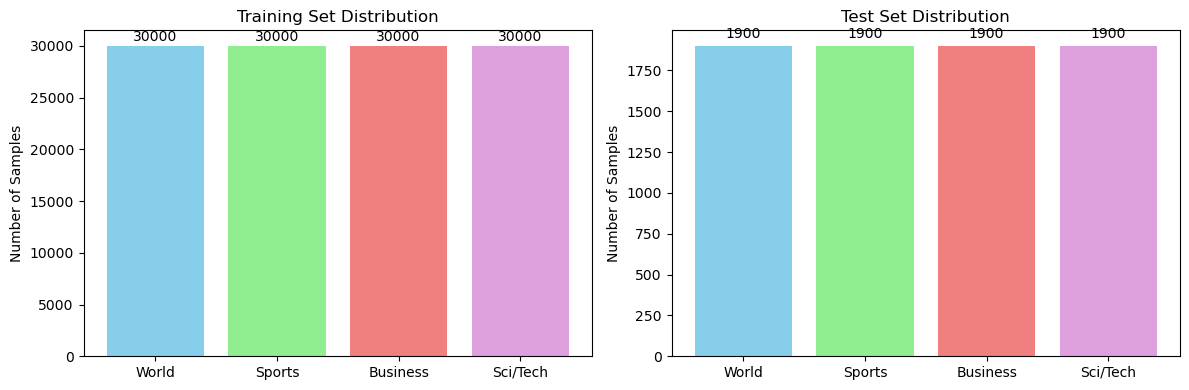

 Dataset is balanced (equal samples per category)


In [5]:
print("\n STEP 2: Analyzing data distribution...")

train_labels = dataset['train']['label']
test_labels = dataset['test']['label']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_counts = [train_labels.count(i) for i in range(4)]
axes[0].bar(label_names, train_counts, color=['skyblue', 'lightgreen', 'lightcoral', 'plum'])
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(train_counts):
    axes[0].text(i, v + 500, str(v), ha='center')

# Test set distribution
test_counts = [test_labels.count(i) for i in range(4)]
axes[1].bar(label_names, test_counts, color=['skyblue', 'lightgreen', 'lightcoral', 'plum'])
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate(test_counts):
    axes[1].text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

print(" Dataset is balanced (equal samples per category)")

In [6]:
print("\n STEP 3: Initializing BERT tokenizer...")

model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

# Test tokenizer
test_text = "Apple launches new iPhone with amazing AI features!"
tokens = tokenizer.tokenize(test_text)
print(f"\nTokenizer test:")
print(f"Original: {test_text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {tokenizer.encode(test_text)}")



 STEP 3: Initializing BERT tokenizer...

Tokenizer test:
Original: Apple launches new iPhone with amazing AI features!
Tokens: ['apple', 'launches', 'new', 'iphone', 'with', 'amazing', 'ai', 'features', '!']
Token IDs: [101, 6207, 18989, 2047, 18059, 2007, 6429, 9932, 2838, 999, 102]


In [7]:
print("\n STEP 4: Tokenizing dataset (this will take 2-3 minutes)...")

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize datasets
tokenized_train = dataset['train'].map(tokenize_function, batched=True)
tokenized_test = dataset['test'].map(tokenize_function, batched=True)

print(" Tokenization complete!")

# Set format for PyTorch
tokenized_train.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

print(f"\nTraining samples ready: {len(tokenized_train):,}")
print(f"Test samples ready: {len(tokenized_test):,}")


 STEP 4: Tokenizing dataset (this will take 2-3 minutes)...


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

 Tokenization complete!

Training samples ready: 120,000
Test samples ready: 7,600


In [8]:
print("\n STEP 5: Loading pre-trained BERT model...")

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)

print(f" Model loaded successfully!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


 STEP 5: Loading pre-trained BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model loaded successfully!
Total parameters: 109,485,316
Trainable parameters: 109,485,316


In [10]:
print("\n STEP 6: Configuring training arguments...")

training_args = TrainingArguments(
    # Output settings
    output_dir='./results',
    
    eval_strategy="epoch",           
    save_strategy="epoch",
    
    # Training parameters
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    weight_decay=0.01,
    
    # Logging
    logging_dir='./logs',
    logging_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    
    # Performance
    fp16=False,
    dataloader_num_workers=2,
    
    report_to="none",                  
    disable_tqdm=False,                
)

print(" Training arguments configured!")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Evaluation strategy: {training_args.eval_strategy}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



 STEP 6: Configuring training arguments...
 Training arguments configured!
Epochs: 1
Batch size: 16
Learning rate: 2e-05
Evaluation strategy: IntervalStrategy.EPOCH


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    return {'accuracy': accuracy, 'f1_score': f1}


In [ ]:
print("\n" + "="*60)
print(" STEP 7: Creating trainer and starting training...")
print("="*60)

# Create trainer WITHOUT tokenizer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print(" Trainer created successfully!")

# Save tokenizer separately (we'll do this after training)
print(" Note: Tokenizer will be saved separately after training")

# Start training
print("\n Starting training...")
print("-" * 40)
trainer.train()

print("\n Training complete!")

# After training, save tokenizer
print("\n Saving tokenizer...")
tokenizer.save_pretrained("./bert_news_classifier")
print(" Tokenizer saved!")

In [ ]:
print("\n STEP 8: Evaluating model...")

eval_results = trainer.evaluate()

print("\n" + "="*50)
print(" EVALUATION RESULTS")
print("="*50)
print(f"Accuracy:  {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1 Score:  {eval_results['eval_f1_score']:.4f}")
print(f"Loss:      {eval_results['eval_loss']:.4f}")

In [ ]:
print("\n STEP 9: Generating detailed report...")

# Get predictions
predictions = trainer.predict(tokenized_test)
predicted_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# Classification report
print("\n" + "="*50)
print(" DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_labels, predicted_labels, 
                           target_names=label_names, 
                           digits=4))

In [ ]:
print("\n STEP 10: Creating confusion matrix...")

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, 
            yticklabels=label_names)
plt.title('Confusion Matrix - BERT News Classifier', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n Per-class Accuracy:")
for i in range(4):
    correct = cm[i, i]
    total = cm[i, :].sum()
    accuracy = correct / total * 100
    print(f"  {label_names[i]}: {correct}/{total} = {accuracy:.2f}%")

In [ ]:
print("\n STEP 11: Testing with custom headlines...")

def predict_news(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class].item()
    
    return label_names[predicted_class], confidence, probabilities[0].cpu().numpy()

# Test examples
test_headlines = [
    "World leaders gather for climate summit in Paris",
    "Manchester United wins Champions League in dramatic final",
    "Stock market reaches all-time high as tech companies surge",
    "NASA discovers new exoplanet with potential for life",
    "New study reveals benefits of Mediterranean diet for heart health"
]

print("\n" + "="*60)
for headline in test_headlines:
    category, confidence, probs = predict_news(headline)
    print(f"\n Headline: {headline}")
    print(f"     Predicted: {category} (confidence: {confidence:.2%})")


In [ ]:
print("\n STEP 12: Saving model...")

# Create model directory
model_save_path = "./bert_news_classifier"
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label mapping
label_mapping = {i: name for i, name in enumerate(label_names)}
with open(f"{model_save_path}/label_mapping.json", 'w') as f:
    json.dump(label_mapping, f)

# Save results
results = {
    'accuracy': eval_results['eval_accuracy'],
    'f1_score': eval_results['eval_f1_score'],
    'loss': eval_results['eval_loss']
}
with open(f"{model_save_path}/results.json", 'w') as f:
    json.dump(results, f)

print(f" Model saved to: {os.path.abspath(model_save_path)}")
print(f"Files saved:")
for file in os.listdir(model_save_path):
    print(f"  - {file}")


In [ ]:
print(f"\n MODEL PERFORMANCE:")
print(f"  • Accuracy:  {results['accuracy']:.2%}")
print(f"  • F1 Score: {results['f1_score']:.4f}")